In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, Ridge
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
model = PolynomialFeatures(degree=3, include_bias=False)

model.fit_transform([[2, 3], 
                     [4, 5]])

array([[  2.,   3.,   4.,   6.,   9.,   8.,  12.,  18.,  27.],
       [  4.,   5.,  16.,  20.,  25.,  64.,  80., 100., 125.]])

# Створення поліноміальних ознак

[[a1=2, b1=3], 
 [a2=4, b2=5]]

[a1, b1, a1^2, a1 * b1, b1^2, a1^3, a1^2 * b1, b1^2 * a1, b1^3]
[a2, b2, a2^2, a2 * b2, b2^2, a2^3, a2^2 * b2, b2^2 * a2, b2^3]

In [3]:
np.random.seed(42)
x = np.linspace(-3, 3, 200)
y = 1.5 * x - 0.8 * x ** 2 + 2 + np.random.normal(0, 1.2, size=200)
X = x.reshape(-1, 1)

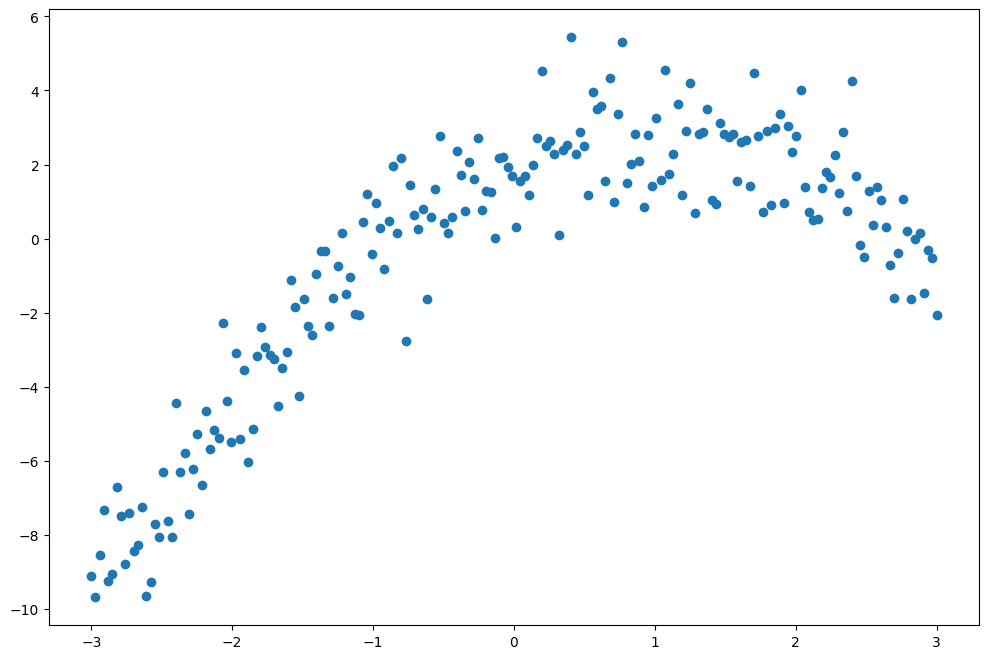

In [4]:
plt.figure(figsize=(12, 8))

plt.scatter(x, y)

plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

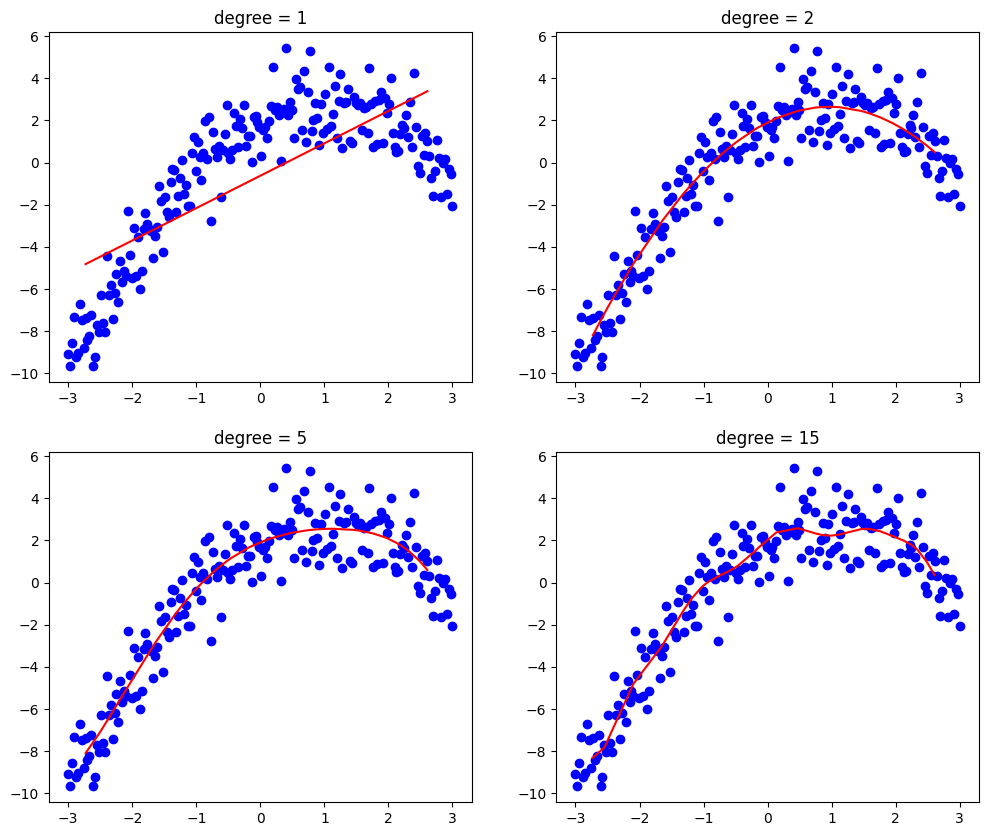

In [6]:
metrics = []

plt.figure(figsize=(12, 10))

result = []

n = 0
for d in [1, 2, 5, 15]:
    n += 1
    plt.subplot(2, 2, n)
    
    model = Pipeline(steps=[
        ("poly", PolynomialFeatures(d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ])
    
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    plt.scatter(x, y, color='blue')
    indx_sort = np.argsort(X_test[:, 0])
    plt.plot(X_test[indx_sort], y_pred_test[indx_sort], color='red')
    
    result.append({
        "index": indx_sort,
        "X_test": X_test[indx_sort],
        "y_pred_test": y_pred_test[indx_sort]
    })
    
    plt.title("degree = " + str(d))
    
    metrics.append({
        "degree": d,
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_test": r2_score(y_test, y_pred_test)
    })
    
plt.show()


In [7]:
pd.DataFrame(result)

,index,X_test,y_pred_test
0,"[30, 1, 21, 31, 2, 9, 32, 16, 25, 24, 10, 27, ...","[[-2.728643216080402], [-2.5477386934673367], ...","[-4.8209445220876725, -4.542637443375454, -4.4..."
1,"[30, 1, 21, 31, 2, 9, 32, 16, 25, 24, 10, 27, ...","[[-2.728643216080402], [-2.5477386934673367], ...","[-8.198908473865838, -7.161806058452766, -6.99..."
2,"[30, 1, 21, 31, 2, 9, 32, 16, 25, 24, 10, 27, ...","[[-2.728643216080402], [-2.5477386934673367], ...","[-8.097761582773366, -7.308432228120482, -7.16..."
3,"[30, 1, 21, 31, 2, 9, 32, 16, 25, 24, 10, 27, ...","[[-2.728643216080402], [-2.5477386934673367], ...","[-8.323047925018045, -7.8196540763248095, -7.6..."


In [8]:
pd.DataFrame(metrics)

,degree,r2_train,r2_test
0,1,0.548510,0.492246
1,2,0.907735,0.897404
2,5,0.911491,0.900050
3,15,0.914993,0.894905


In [9]:
X, y = make_regression(n_samples=500, n_features=20, n_informative=5, noise=10, random_state=42)

In [10]:
print(X.shape, y.shape)

(500, 20) (500,)


In [11]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:


models = {
    "LinearRegression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Lasso": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=1.0, max_iter=1000))
    ]),
    "Ridge": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=0.1))
    ])
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    coef = model.named_steps['model'].coef_
    print(coef)
    non_zero = np.sum(np.abs(coef) > 0.0000001)
    rows.append({
        "model": name,
        "r2": r2_score(y_test, y_pred),
        "non_zero": non_zero
    })

[-4.75955982e-02  4.46077211e-01  7.50995674e+00 -5.39804192e-01
 -4.18941644e-01  3.47925118e-01  6.07639349e+01  3.12934456e+01
  2.31913539e-01  1.02167905e+01 -8.29251365e-01  1.82408073e-02
  7.58527053e-01  9.02002417e+00 -6.72314083e-02 -7.11478775e-03
  9.80874687e-02  2.33412456e-02  6.87074245e-01 -9.47227371e-02]
[-0.          0.          6.39754235 -0.         -0.          0.
 59.74388512 30.29295734  0.          9.39506182 -0.          0.
  0.          8.040803   -0.         -0.          0.         -0.
  0.         -0.        ]
[-4.74157617e-02  4.45274696e-01  7.50865744e+00 -5.39705848e-01
 -4.19281570e-01  3.47982248e-01  6.07484168e+01  3.12852924e+01
  2.31791700e-01  1.02143830e+01 -8.28479642e-01  1.97816098e-02
  7.57654183e-01  9.01772484e+00 -6.71586238e-02 -7.77769806e-03
  9.76241248e-02  2.32329689e-02  6.87185418e-01 -9.63884458e-02]


In [13]:
pd.DataFrame(rows)

,model,r2,non_zero
0,LinearRegression,0.978411,20
1,Lasso,0.979109,5
2,Ridge,0.978419,20


In [19]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

housing_df = fetch_california_housing(as_frame=True).frame

X = housing_df.drop(columns=["MedHouseVal"])
y = housing_df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

trees = [
    {
        "model_name": "DecisionTreeRegressor",
        "model": DecisionTreeRegressor(max_depth=10, random_state=42)
    },
    {
        "model_name": "RandomForestRegressor",
        "model": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    },
    {
        "model_name": "GradientBoostingRegressor",
        "model": GradientBoostingRegressor(n_estimators=100, max_depth=10, random_state=42)
    }
]

metrics = []

for tree in trees:
    model = tree['model']
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    
    metrics.append({
        "model": tree['model_name'],
        "r2_train": r2_score(y_train, y_train_pred),
        "r2_test": r2_score(y_test, y_pred),
        "mae": mean_absolute_error(y_test, y_pred)
    })
    

metrics_df = pd.DataFrame(metrics)
metrics_df

,model,r2_train,r2_test,mae
0,DecisionTreeRegressor,0.834778,0.682169,0.433488
1,RandomForestRegressor,0.871923,0.773768,0.366316
2,GradientBoostingRegressor,0.986524,0.828029,0.305548


In [20]:
from sklearn.datasets import load_breast_cancer


df = load_breast_cancer(as_frame=True).frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [26]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

metrics = pd.DataFrame([{
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred)
}])
metrics



,accuracy,precision,recall,f1_score
0,0.982456,0.986111,0.986111,0.986111


In [28]:
cm = confusion_matrix(y_test, y_pred)
pd.DataFrame(cm, index=['real 0', 'real 1'], columns=['pred 0', 'pred 1'])

,pred 0,pred 1
real 0,41,1
real 1,1,71


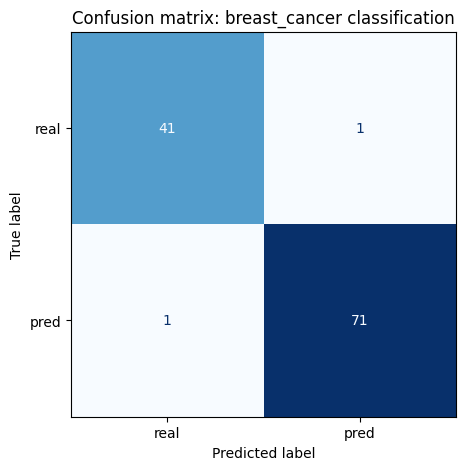

In [33]:
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['real', 'pred'])
fig, ax = plt.subplots(figsize=(6, 5))
display_cm.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix: breast_cancer classification")
plt.show()